# NBA Scrapper using py_ball

In [1]:
%pip install nba_api pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install numpy==1.23.5 --force-reinstall
%pip install matplotlib --force-reinstall


  Using cached numpy-1.23.5-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nba-api 1.9.0 requires numpy>=1.26.0; python_version < "3.13", but you have numpy 1.23.5 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
  Using cached matplotlib-3.10.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.6 MB)
  Using cached packaging-25.0-py3-none-any.whl (66 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
  Using cached pillow-11.2.1-cp310-cp310-manylinux_2_28_x86_64.whl (4.6 MB)
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
 

In [ ]:
from nba_api.stats.static import teams
import pandas as pd
from datetime import datetime, timedelta
from src.config import *
from src.utils import *
import time

#today formated as YYYY-MM-DD
today = datetime.today().strftime('%Y-%m-%d')
today_precise = datetime.today().strftime('%Y-%m-%d_%H-%M-%S')

## Fetch Players data

In [5]:
import pandas as pd
from nba_api.stats.static import players
import os


#load all boxscores files from the lastest file

boxscores_file = get_latest_file(DATA_BOXSCORES_BATCHES_MERGED_DIR)

boxscores_df = pd.read_csv(boxscores_file, low_memory=False)

# 1. Get all player IDs seen in the boxscores
player_ids_seen = set(boxscores_df['PLAYER_ID'].dropna().astype(int).unique())

# 2. Get all NBA players (historical and active)
nba_players = players.get_players()
nba_players_df = pd.DataFrame(nba_players)
nba_players_df['id'] = nba_players_df['id'].astype(int)

# 3. Add flag: has this player been seen in your dataset?
nba_players_df['in_boxscore'] = nba_players_df['id'].isin(player_ids_seen)

# (Optionnel) Add "nb_appearances" (number of games in boxscores for each player)
counts = boxscores_df['PLAYER_ID'].value_counts().astype(int)
nba_players_df['nb_appearances'] = nba_players_df['id'].map(counts).fillna(0).astype(int)

# 4. Save the complete master file
#nba_players_df.to_csv(os.path.join(DATA_PLAYERS_DIR, 'players_master.csv'), index=False)

save_dataframe_to_csv(nba_players_df, DATA_PLAYERS_DIR, prefix='players_master_', suffix=today_precise)

print("✅ Players master file saved with historicals and seen flags!")


✅ Players master file saved with historicals and seen flags!


## Quick visualization

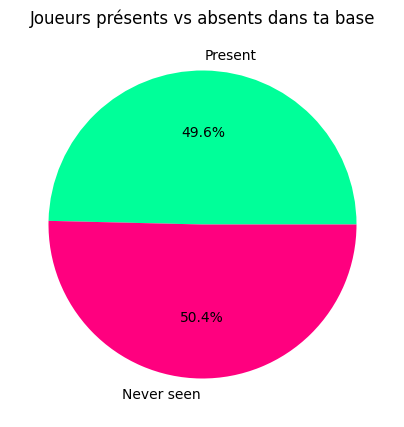

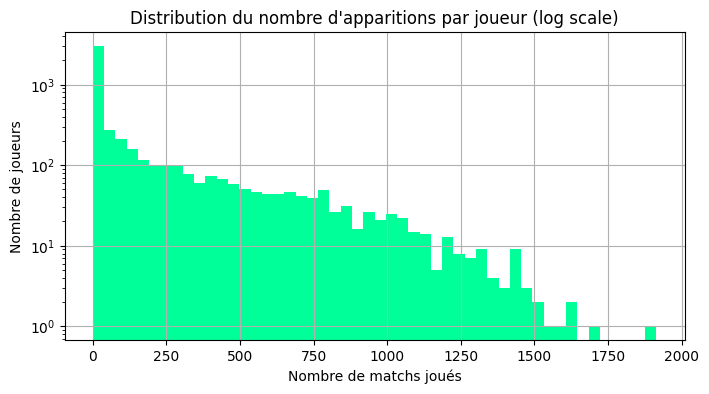

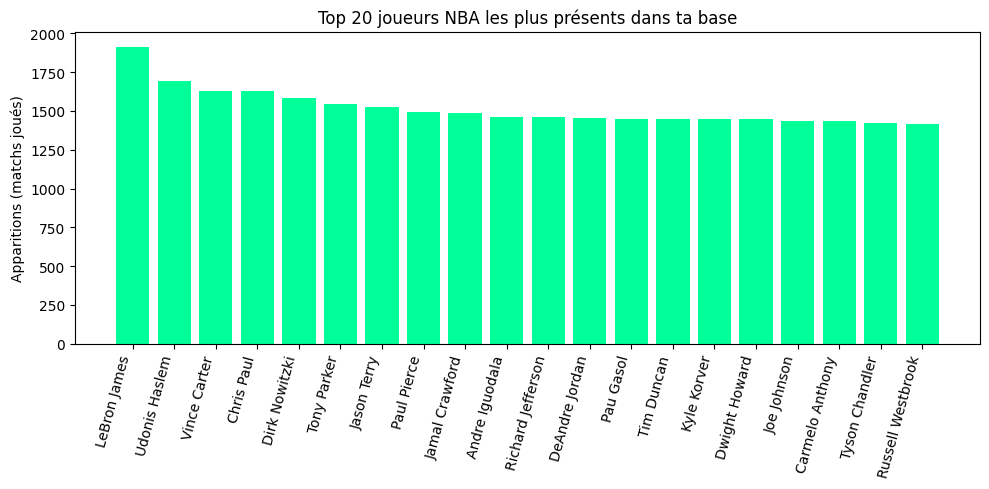

2531 joueurs historiques jamais vus dans tes boxscores !


,id,full_name,first_name,last_name,is_active,in_boxscore,nb_appearances
1110,76567,Coby Dietrick,Coby,Dietrick,False,False,0
4021,78128,Ron Shavlik,Ron,Shavlik,False,False,0
340,76162,Henry Bibby,Henry,Bibby,False,False,0
1706,1575,Derek Grimm,Derek,Grimm,False,False,0
2058,77076,Alfredrick Hughes,Alfredrick,Hughes,False,False,0
3499,456,Chuck Person,Chuck,Person,False,False,0
3143,77648,Dwight Morrison,Dwight,Morrison,False,False,0
3885,78048,Walker Russell,Walker,Russell,False,False,0
3150,77654,Perry Moss,Perry,Moss,False,False,0
131,76056,Paul Arizin,Paul,Arizin,False,False,0


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Charge ton master file
players_master = pd.read_csv(get_latest_file(DATA_PLAYERS_DIR))

# 1. Combien de joueurs présents vs absents dans tes datas
present = players_master['in_boxscore'].sum()
total = len(players_master)
absents = total - present

plt.figure(figsize=(5, 5))
plt.pie([present, absents], labels=['Present', 'Never seen'], autopct='%1.1f%%', colors=['#00FF99', '#FF007F'])
plt.title("Joueurs présents vs absents dans ta base")
plt.show()

# 2. Distribution du nombre d'apparitions (log pour voir les extrêmes)
plt.figure(figsize=(8, 4))
players_master['nb_appearances'].hist(bins=50, log=True, color='#00FF99')
plt.title("Distribution du nombre d'apparitions par joueur (log scale)")
plt.xlabel("Nombre de matchs joués")
plt.ylabel("Nombre de joueurs")
plt.show()

# 3. Top 20 joueurs les plus présents
top20 = players_master.sort_values('nb_appearances', ascending=False).head(20)
plt.figure(figsize=(10, 5))
plt.bar(top20['full_name'], top20['nb_appearances'], color='#00FF99')
plt.title("Top 20 joueurs NBA les plus présents dans ta base")
plt.xticks(rotation=75, ha='right')
plt.ylabel("Apparitions (matchs joués)")
plt.tight_layout()
plt.show()

# 4. Pour le fun : joueurs jamais vus (curiosité)
never_seen = players_master[~players_master['in_boxscore']]
print(f"{len(never_seen)} joueurs historiques jamais vus dans tes boxscores !")
display(never_seen.sample(10))
